# ReadSim Tutorial

In [8]:
import numpy as np
import os
import sys
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

import gzip
from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
simdir = "/Users/kyle/Documents/Code/cgshells/data/examples/2d/md/phi-0.100/kT-0.100"
result = ReadSim(simdir)
result.files

['restart.final',
 'metadata.yaml',
 'in.lammps',
 'trajectory1.dump.gz',
 'data.lammps.gz',
 'log.lammps']

In [3]:
result.latest_file(file="log")

'log.lammps'

In [4]:
result.latest_file(file="trajectory",return_matches=True)

('trajectory1.dump.gz', ['trajectory1.dump.gz'])

# Listing all files in simulation directory

In [3]:
simdir = "readsimfiles" 
result = ReadSim(simdir)
result.files

['complete.dump',
 'complete.dump.gz',
 'incomplete.dump.gz',
 'logemin.lammps',
 'logmd.lammps',
 'incomplete.dump']

In [12]:
os.path.exists(f'{simdir}/complete.dump')

True

### Finding latest trajectory file if there are multiple in simulation directory

In [25]:
def latest_traj(files):
    # collect trajectory files
    trajectories = []
    for f in files:
        if f[:10] == "trajectory":
            trajectories.append(f)

    # find latest trajectory file
    tlast = 0
    restart = 0
    for i in np.arange(len(trajectories)):
        traj = trajectories[i]
        p = traj.index(".")
        n = int(traj[10:p])
        if n > restart:
            tlast = i
            restart = n
    dumpname = trajectories[tlast]
    return dumpname

files = ['log.lammps','trajectory1.dump.gz','trajectory3.dump.gz',
         'trajectory10.dump.gz','trajectory2.dump.gz']

latest_traj(files)

'trajectory10.dump.gz'

# Reading log files

### General use and common attributes

In [15]:
simdir = "readsimfiles" 
logname = "log1.lammps"
logname = "logmd.lammps"
# logname = "logemin.lammps"
result = ReadSim(simdir)
result.read_log(logname=logname,latest=False)

### attributes available after reading
result.walltime_hms    # simulation wall time (string formatted as hrs:min:sec)
result.walltime    # simulation wall time (int-type in seconds)
result.sim_type    # type of simulation, energy min. or molecular dynamics
result.thermo    # content of thermodynamic output
# result.thermo_labels    # labels of each column of thermo output


array([[ 0.0000000e+00,  2.2561721e+02,  0.0000000e+00, ...,
         2.2547307e+02,  0.0000000e+00, -1.3810409e-02],
       [ 5.0000000e+05,  8.4722294e+02,  4.2663179e+02, ...,
         4.2373352e+02,  7.1117151e-02,  1.0343272e-02],
       [ 1.0000000e+06,  8.3596201e+02,  4.1921221e+02, ...,
         4.2001162e+02,  6.9880349e-02,  3.9952829e-03],
       ...,
       [ 4.9900000e+08,  8.1248614e+02,  4.0455568e+02, ...,
         4.2695251e+02,  6.7437186e-02, -1.5179798e-02],
       [ 4.9950000e+08,  8.2463681e+02,  4.1892897e+02, ...,
         4.2324383e+02,  6.9833133e-02,  4.7912323e-03],
       [ 5.0000000e+08,  8.3369049e+02,  4.2045368e+02, ...,
         4.3120292e+02,  7.0087294e-02,  3.7783332e-04]])

In [10]:
result.thermo_Step[-1]

500000000.0

In [12]:
len(result.thermo_Step)

1001

In [15]:
result.thermo_TotEng

array([-831.21184, -831.26571, -831.27808, -831.28084, -831.28174,
       -831.284  , -831.28638, -831.28812, -831.2892 , -831.2897 ,
       -831.28997, -831.29043, -831.29054, -831.29055, -831.29056])

result.thermo_labels[i] tells you what the data result.thermo[:,i] is.

Each column of data in result.thermo can be called by name if labelled correctly (e.g no brackets).  
E.g Total energy is "TotEng" so we can call it with result.thermo_TotEng

In [16]:
result.thermo[:,1]

array([-831.21184, -831.26571, -831.27808, -831.28084, -831.28174,
       -831.284  , -831.28638, -831.28812, -831.2892 , -831.2897 ,
       -831.28997, -831.29043, -831.29054, -831.29055, -831.29056])

In [9]:
result.thermo_TotEng

array([225.61721, 847.22294, 835.96201, ..., 812.48614, 824.63681,
       833.69049])

In [10]:
result.thermo_E_bond[-1]

431.20292

Text(0, 0.5, 'total energy')

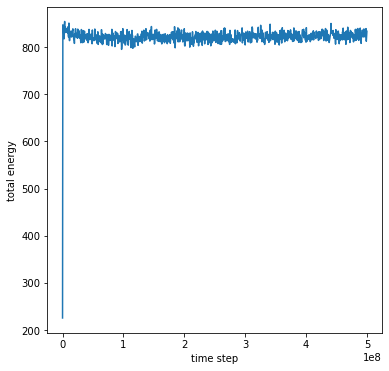

In [6]:
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.plot(result.thermo_Step,result.thermo_TotEng)
ax.set_xlabel("time step")
ax.set_ylabel("total energy")

### Energy minimization attributes

In [12]:
simdir = "readsimfiles" 
# logname = "logmd.lammps"
logname = "logemin.lammps"
result = ReadSim(simdir)
result.read_log(logname=logname)

result.energyi    # initial energy
result.energyf    # final energy
result.energy2    # second to last step energy
result.why_stop    # stopping reason

'energy tolerance'

In [17]:
frame = 1
(frame==-1)or(frame==0)

False

# Reading dump files

In [7]:
### read dump file
simdir = "readsimfiles" 
dumpname = "complete.dump.gz"
readall = False

result = ReadSim(simdir)
result.read_dump(dumpname=dumpname,readall=readall)


In [9]:
### attributes available after reading
result.natoms    # number of atoms in simulation
result.nframes    # number of completed dumps in file
result.dump_i    # np array of all data in first dump (initial state)
result.tstep_i    # timestep of first dump
result.dump_f    # np array of all data in last dump (last timestep)
                       # if writing process was interrupted this will return last complete step
result.tstep_f    # timestep of last completed dump
result.dumps    # data from each dump collected with read_dump command
result.tsteps    # timesteps associated with each dump
result.dump_labels    # labels of dump file data columns
result.boundary_types    # sim box boundary types (e.g periodic, shrink-wrapped)
result.boxdims    # array of sim box dimensions
result.xlo    # sim box xlo
result.xhi
result.ylo
result.yhi
result.zlo
result.zhi

0.5

In [19]:
result.dumps[0][120]

array([  2.    , 121.    ,   1.    ,  74.9181, -77.677 ,   0.    ])

In [7]:
np.max(result.dump_mol[-1])

50.0

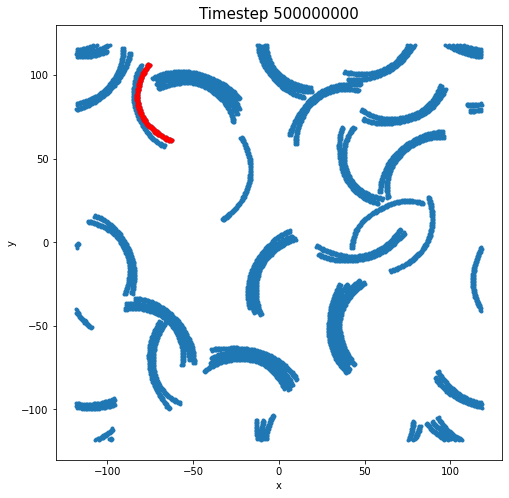

In [10]:
frame = -1
mol = 11
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(result.dump_x[frame],result.dump_y[frame],".")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {}".format(result.tsteps[frame]),fontsize=15)

mask = (result.dump_mol[frame]==mol)
ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask],"r.")

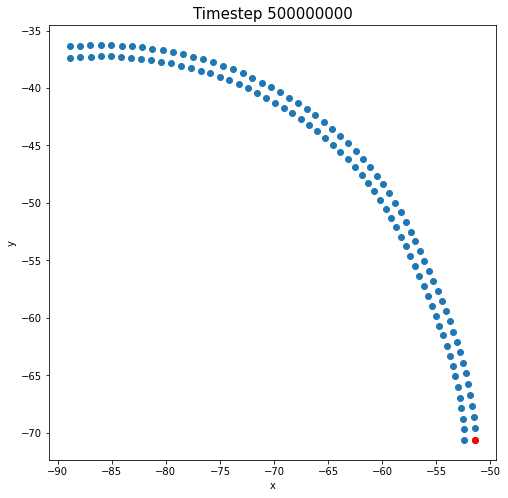

In [40]:
frame = -1
mol = 1
fig, ax = plt.subplots(1,1,figsize=(8,8))
# ax.plot(result.dump_x[frame],result.dump_y[frame],".")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {}".format(result.tsteps[frame]),fontsize=15)

mask = (result.dump_mol[frame]==mol)
ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask],"o")


rtop = (result.dump_id[frame]==120)
ax.plot(result.dump_x[frame][rtop],result.dump_y[frame][rtop],"ro")

In [29]:
result.dump_id[frame][mask] == 60

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [19]:
nbeads = int(np.max(result.dump_id[frame][mask])/2)
nbeads

60

In [16]:
len(result.dump_f)

46080

In [17]:
result.natoms

46080

In [23]:
dumpname[-3:] == ".gz"

False

In [64]:
1//4 + 1

1

In [16]:
"{}-1".format(os.path.splitext(os.path.basename(sys.argv[0]))[0])

'ipykernel_launcher-1'

In [73]:
Nmols

20

In [2]:
simdir = "/Users/kyle/Documents/Code/cgshells/data/2d/sigma-1.000-kh-1000.00/nshells-30"
logname="log.lammps"
result = ReadSim(simdir)
result.read_log(logname=logname)
result.why_stop

'walltime limit reached'

In [9]:
simdir = "/Users/kyle/Documents/Code/cgshells/data/2d/sigma-1.000-kh-1000.00/nshells-30"
logname="log.lammps"
# simdir = "/Users/kyle/Documents/Code/cgshells/reference/readsimfiles"
# logname="logemin.lammps"
opened = open("{}/{}".format(simdir,logname))
in_text = opened.read()
opened.close()

# thermo output
start_index = in_text.index("Step")
end_index = in_text.index("\n",start_index)
thermo_labels = in_text[start_index : end_index].split() 
nlabels = len(thermo_labels)
loop_index = in_text.index("Loop")
try:
    warning_index = in_text.index("WARNING:",end_index)
    warning_stop = in_text.index("\n",warning_index)+len("\n")
    thermo_stop = warning_index
    extra = in_text[warning_stop:loop_index]
    thermostring = in_text[end_index:thermo_stop]+extra
except:
    thermo_stop = loop_index
    thermostring = in_text[end_index:thermo_stop]

lines = 0 
for i in thermostring:#in_text[start_index:thermo_stop]:
    if i=="\n":
        lines += 1

thermo = np.fromstring(thermostring,sep="\n").reshape(lines-1,nlabels)
# for i in range(nlabels):
#     setattr(self,"thermo_"+self.thermo_labels[i],self.thermo[:,i])

In [ ]:
why_stop

In [4]:
thermostring

'\n         0  -831.21184     -831.21184      0              8.1464427    \n       100  -831.26571     -831.26571      0              7.76775      \n       200  -831.27808     -831.27808      0              7.5347529    \n       300  -831.28084     -831.28084      0              7.4819643    \n       400  -831.28174     -831.28174      0              7.4648302    \n       500  -831.284       -831.284        0              7.4220898    \n       600  -831.28638     -831.28638      0              7.3764648    \n       700  -831.28812     -831.28812      0              7.3438046    \n       800  -831.2892      -831.2892       0              7.3231264    \n       900  -831.2897      -831.2897       0              7.313761     \n      1000  -831.28997     -831.28997      0              7.3085723    \n      1100  -831.29043     -831.29043      0              7.2999101    \n      1200  -831.29054     -831.29054      0              7.2978738    \n      1300  -831.29055     -831.29055      0    

In [8]:
thermo[-1]

array([1376.       , -831.29056  , -831.29056  ,    0.       ,
          7.2973224])

In [44]:
in_text[end_index:thermo_stop]+extra

'\n         0  -51.25699       0             -51.25699      -88.315144      37.058154      0              0.018535646  \n       100  -61.46415       0             -61.46415      -89.340466      27.876316      0             -0.082525773  \n       200  -66.24468       0             -66.24468      -89.702851      23.458171      0             -0.030128656  \n       300  -68.476503      0             -68.476503     -89.769296      21.292793      0             -0.029801766  \n       400  -71.583914      0             -71.583914     -89.30114       17.717225      0             -0.0065252777 \n       500  -72.697254      0             -72.697254     -89.766512      17.069258      0              0.0027413729 \n       600  -73.078268      0             -73.078268     -89.671722      16.593454      0             -0.0005830603 \n       700  -73.272186      0             -73.272186     -89.545264      16.273078      0              0.0060116932 \n       800  -73.396326      0             -73.396326 

In [28]:
in_text[warning_index:warning_index + len("WARNING: Wall time limit reached (../timer.cpp:193)\n")]

'WARNING: Wall time limit reached (../timer.cpp:193)\n'

In [61]:
warning_index

40290

In [2]:
### read dump file
simdir = "/Users/kyle/Documents/Code/cgshells" 
dumpname = "trajectory2.dump.gz"
readall = False

result = ReadSim(simdir)
result.read_dump(dumpname=dumpname,readall=readall)

In [3]:
result.nframes

1

In [4]:
result.dump_f

array([[ 1.00000e+00,  1.00000e+00,  6.00000e+00, -1.42537e+01,
         1.47301e+01, -4.59427e+00],
       [ 1.00000e+00,  2.00000e+00,  3.00000e+00, -1.54900e+01,
         1.48184e+01, -3.37005e-01],
       [ 1.00000e+00,  3.00000e+00,  6.00000e+00, -1.41016e+01,
         1.50046e+01, -4.55607e+00],
       ...,
       [ 1.20000e+01,  2.55742e+05,  3.00000e+00,  1.57289e+01,
        -1.45364e+01,  6.03127e+01],
       [ 1.20000e+01,  2.55743e+05,  6.00000e+00,  1.49166e+01,
        -1.49831e+01,  5.59449e+01],
       [ 1.20000e+01,  2.55744e+05,  3.00000e+00,  1.57292e+01,
        -1.50840e+01,  6.03006e+01]])

In [2]:
simdir ="/Users/kyle/Documents/Code/cgshells/data/2d/mesh_characteristics/wx-18.670-t0-1.000-Nbeads-20/interactions/1patch/sigma-0.25000-epsilon-1.00000-soft-False/correct/ysep-1.600"
# dumpname = "trajectory2.dump.gz"
readall = False

result = ReadSim(simdir)
# result.read_dump(dumpname=dumpname,readall=readall)
result.read_log()

In [3]:
result.thermo

array([[ 0.0000000e+00,  5.6211405e+05,  0.0000000e+00,  5.6211405e+05,
         5.6211405e+05,  0.0000000e+00,  0.0000000e+00, -3.5078032e+05],
       [ 1.0000000e+00,  5.6211405e+05,  0.0000000e+00,  5.6211405e+05,
         5.6211405e+05,  0.0000000e+00,  0.0000000e+00, -3.5078032e+05]])

In [45]:
simdir = "/Users/kyle/Documents/Code/cgshells/outputs/Nbeads-15-damp-100"
logs = ["nshells-400-phi-0.20000-kT-0.10000-51698995.out",
        "nshells-400-phi-0.20000-kT-0.10000-51740264.out",
        "nshells-400-phi-0.20000-kT-0.10000-51724959.out",
        "nshells-400-phi-0.20000-kT-0.10000-51755584.out"]
temps = []
steps = []
engs = []

for logname in logs:
    result = ReadSim(simdir)
    result.read_log(logname=logname)
    temp = result.thermo_Temp
    step = result.thermo_Step
    eng = result.thermo_TotEng
    for i in np.arange(len(step)):
        temps.append(temp[i])
        steps.append(step[i])
        engs.append(eng[i])

(0.0, 0.15451311)

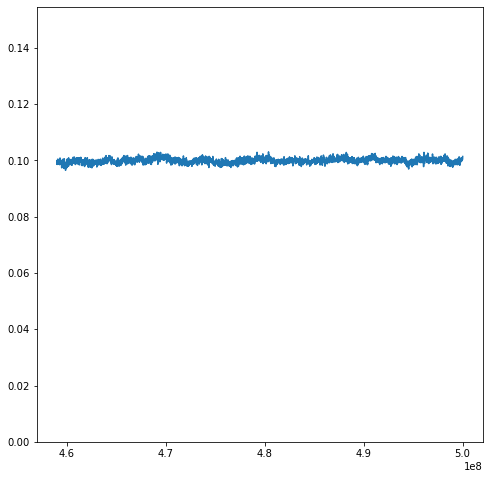

In [47]:

fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(np.array(step),np.array(temp))
ax.set_ylim(0,1.5*np.max(temp))
# ax.plot(np.array(step),np.array(eng),"r")
# ax.set_ylim(0,1.5*np.max(eng))

In [22]:
temp

array([0.        , 0.09858677, 0.10449282, ..., 0.09948872, 0.09968085,
       0.0998937 ])

In [29]:
eng[-10000]

1446.4861

In [18]:
result.thermo_labels

['Step', 'TotEng', 'KinEng', 'PotEng', 'E_pair', 'E_bond', 'Temp', 'Press']

In [21]:
result.thermo[:,1]

array([ 422.44915,  889.49117,  931.29675, ..., 1942.3934 , 1945.7544 ,
       1961.414  ])

In [30]:
result.thermo_TotEng

array([ 422.44915,  889.49117,  931.29675, ..., 1942.3934 , 1945.7544 ,
       1961.414  ])